# Лабораторная работа №5
## Рекомендации по формализации и расчётам характеристик подсистем КИС в виде разомкнутых или замкнутых стохастических моделей

**Вариант:** 19

---

### Введение

В данной работе моделируются два типичных стохастических процесса корпоративной информационной системы (КИС):

1. **Задание 1.** Многоканальная **разомкнутая** система массового обслуживания $M/M/n/m$ с **отказами и восстановлением каналов**. Заявка с отказавшего канала возвращается в очередь, если в ней есть место, иначе теряется. Строятся:
    - матрица интенсивностей переходов (генератор Марковского процесса);
    - дифференциальные уравнения Колмогорова и их численное решение методом Рунге–Кутты 4-го порядка;
    - стационарное распределение и теоретические характеристики (вероятности простоя/очереди, пропускная способность, средние длины и времена);
    - имитационная модель методом Гиллеспи для верификации теории;
    - сравнение влияния «+1 канал» против «+1 место в очереди» на пропускную способность.

2. **Задание 2 (доп).** Имитация маршрутизации пакета в сети с топологией **кольцо** с учётом случайных отказов компьютеров-адресатов и ограничения TTL.

Все вычисления выполняются на языке **R** с использованием `ggplot2` для визуализации, RK4 — для интегрирования системы Колмогорова и встроенных средств линейной алгебры для стационарного распределения.

## Блок 0. Настройка окружения

In [1]:
## Загрузка необходимых пакетов и настройка темы графиков
options(scipen = 999, digits = 6)

load_libs <- function(libs) {
  for (lib in libs) {
    if (!require(lib, character.only = TRUE, quietly = TRUE)) {
      install.packages(lib, dependencies = TRUE, quiet = TRUE)
      library(lib, character.only = TRUE, quietly = TRUE)
    }
  }
}

pkgs <- c("ggplot2", "gridExtra", "dplyr", "tidyr")
load_libs(pkgs)

# Корпоративная тема для графиков
theme_advanced <- function() {
  theme_minimal(base_size = 12) +
    theme(
      plot.title    = element_text(face = "bold", size = 14, hjust = 0.5, color = "#2C3E50"),
      plot.subtitle = element_text(size = 10, hjust = 0.5, color = "#7F8C8D"),
      axis.title    = element_text(face = "bold", color = "#34495E"),
      panel.grid.major = element_line(color = "#D5D8DC", linetype = "dashed"),
      panel.grid.minor = element_blank(),
      legend.position  = "bottom"
    )
}
theme_set(theme_advanced())

cat("Окружение готово.\n")


Attaching package: ‘dplyr’




The following object is masked from ‘package:gridExtra’:

    combine




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Окружение готово.


## Задание 1. Многоканальная СМО с отказами оборудования

### Параметры варианта 19

| Параметр | Значение | Описание |
|:---------|:---------|:---------|
| $\lambda$ | 0.0939198 | Интенсивность поступления заявок |
| $\mu$     | 0.2621519 | Интенсивность обслуживания на канале |
| $\nu$     | 0.1744630 | Интенсивность отказа канала |
| $\gamma$  | 0.6805274 | Интенсивность восстановления канала |
| $n$       | 3         | Количество каналов |
| $m$       | 7         | Ёмкость очереди |
| $k$       | $\infty$  | Количество источников заявок (**разомкнутая система**) |
| $t$       | 0.3693336 | Момент времени для нестационарного режима |
| $P_{(0,n)}(0)$ | 1    | Начально система пуста, все каналы исправны |

### Особенности модели

- Так как $k = \infty$, система **разомкнутая**: интенсивность поступления постоянна и равна $\lambda$, независимо от числа заявок в системе. Если система полна ($i = n + m$), новая заявка получает отказ.
- Канал может выйти из строя с интенсивностью $\nu$ и восстановиться с интенсивностью $\gamma$.
- Если в момент поломки канал был занят заявкой, заявка возвращается в очередь, если там есть свободное место; иначе теряется.
- Максимально в системе одновременно может быть $n + m = 10$ заявок.

### Пространство состояний

Состояние системы — пара $(i, j)$, где
* $i$ — общее число заявок в системе, $0 \le i \le n + m = 10$,
* $j$ — число исправных каналов, $0 \le j \le n = 3$.

Общее число состояний: $S = (n + m + 1) \cdot (n + 1) = 11 \cdot 4 = 44$.

### Интенсивности переходов из $(i, j)$

1. **Поступление** $(i, j) \to (i+1, j)$ с интенсивностью $\lambda$, если $i < n + m$.
2. **Обслуживание** $(i, j) \to (i-1, j)$ с интенсивностью $\min(i, j)\,\mu$ (работают $\min(i,j)$ каналов).
3. **Восстановление** $(i, j) \to (i, j+1)$ с интенсивностью $(n - j)\,\gamma$.
4. **Отказ канала** $(i, j)$ с интенсивностью $j\,\nu$:
   * если $i < j$ — канал, не занятый заявкой, ломается: $(i, j-1)$;
   * если $i \ge j$ и $i < n+m$ — заявка с отказавшего канала уходит в очередь: $(i, j-1)$;
   * если $i = n+m$ — заявка теряется: $(i-1, j-1)$.

### Шаг 1. Построение генератора $Q$

In [2]:
## Параметры варианта 19
lambda <- 0.0939197666
mu     <- 0.2621518595
nu     <- 0.1744629620
gamma  <- 0.6805273918
k      <- Inf        # разомкнутая система
n      <- 3
m      <- 7
target_t <- 0.3693335890

# Максимум заявок в системе
I_max <- n + m

# Нумерация состояний (i, j)
states    <- list()
state_idx <- list()
idx <- 0
for (i in 0:I_max) for (j in 0:n) {
  idx <- idx + 1
  states[[idx]] <- c(i = i, j = j)
  state_idx[[paste(i, j, sep = "_")]] <- idx
}
S <- length(states)
get_idx <- function(i, j) state_idx[[paste(i, j, sep = "_")]]

cat(sprintf("Максимум заявок в системе I_max = n + m = %d\n", I_max))
cat(sprintf("Общее число состояний S = %d\n", S))

# Построение матрицы Q (S x S)
Q <- matrix(0, nrow = S, ncol = S)
for (idx_from in 1:S) {
  s <- states[[idx_from]]
  i <- s["i"]; j <- s["j"]

  # 1) Поступление (разомкнутая система — постоянная интенсивность lambda)
  if (i < I_max) {
    Q[idx_from, get_idx(i + 1, j)] <- Q[idx_from, get_idx(i + 1, j)] + lambda
  }
  # 2) Окончание обслуживания
  if (i > 0 && j > 0) {
    Q[idx_from, get_idx(i - 1, j)] <- Q[idx_from, get_idx(i - 1, j)] + min(i, j) * mu
  }
  # 3) Восстановление канала
  if (j < n) {
    Q[idx_from, get_idx(i, j + 1)] <- Q[idx_from, get_idx(i, j + 1)] + (n - j) * gamma
  }
  # 4) Отказ канала
  if (j > 0) {
    r_fail <- j * nu
    if (i < j) {
      # ломается пустой канал — заявок никто не теряет
      Q[idx_from, get_idx(i, j - 1)] <- Q[idx_from, get_idx(i, j - 1)] + r_fail
    } else if (i < n + m) {
      # заявка с отказавшего канала уходит в очередь
      Q[idx_from, get_idx(i, j - 1)] <- Q[idx_from, get_idx(i, j - 1)] + r_fail
    } else {
      # система полна — заявка с отказавшего канала теряется
      Q[idx_from, get_idx(i - 1, j - 1)] <- Q[idx_from, get_idx(i - 1, j - 1)] + r_fail
    }
  }
}
# Диагональ: -(сумма по строке)
for (a in 1:S) Q[a, a] <- -sum(Q[a, -a])

cat(sprintf("\nПроверка: max|rowSums(Q)| = %.2e (должно быть ~0)\n", max(abs(rowSums(Q)))))

Максимум заявок в системе I_max = n + m = 10


Общее число состояний S = 44



Проверка: max|rowSums(Q)| = 1.11e-16 (должно быть ~0)


### Шаг 2. Решение дифференциальных уравнений Колмогорова и стационарное распределение

Численно интегрируем $\dot{P}(t) = P(t)\,Q$ с начальным условием $P_{(0,n)}(0) = 1$ методом Рунге–Кутты 4-го порядка.

Стационарное распределение $\boldsymbol{\pi}$ удовлетворяет $\boldsymbol{\pi}\,Q = 0,\ \sum_a \pi_a = 1$. Решаем линейную систему методом наименьших квадратов (QR-разложение).

In [3]:
## Численное интегрирование методом RK4: dP/dt = P %*% Q
rk4_step <- function(P, dt, Qm) {
  k1 <- as.numeric(P %*% Qm)
  k2 <- as.numeric((P + dt/2 * k1) %*% Qm)
  k3 <- as.numeric((P + dt/2 * k2) %*% Qm)
  k4 <- as.numeric((P + dt   * k3) %*% Qm)
  P + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
}

# Начальное условие
P0 <- rep(0, S)
P0[get_idx(0, n)] <- 1.0

# Интегрирование до target_t с записью траектории
N_steps_t <- 200
dt_t <- target_t / N_steps_t
traj_short <- matrix(0, nrow = N_steps_t + 1, ncol = S + 1)
traj_short[1, ] <- c(0, P0)
P_cur <- P0
for (s_i in 1:N_steps_t) {
  P_cur <- rk4_step(P_cur, dt_t, Q)
  traj_short[s_i + 1, ] <- c(s_i * dt_t, P_cur)
}
P_t <- P_cur

# Длинная траектория для иллюстрации сходимости
T_long <- 30
N_long <- 600
dt_long <- T_long / N_long
traj_long <- matrix(0, nrow = N_long + 1, ncol = S + 1)
traj_long[1, ] <- c(0, P0)
P_cur <- P0
for (s_i in 1:N_long) {
  P_cur <- rk4_step(P_cur, dt_long, Q)
  traj_long[s_i + 1, ] <- c(s_i * dt_long, P_cur)
}

cat(sprintf("Сумма P_t (t = %.4f) = %.10f\n", target_t, sum(P_t)))

# Стационарное распределение: pi*Q = 0, sum(pi)=1
A_mat <- rbind(t(Q), rep(1, S))
b_vec <- c(rep(0, S), 1)
P_inf <- as.numeric(qr.solve(A_mat, b_vec))

cat(sprintf("Сумма P_inf = %.10f\n", sum(P_inf)))
cat(sprintf("min(P_inf)  = %.6e (должно быть >= 0)\n", min(P_inf)))

Сумма P_t (t = 0.3693) = 1.0000000000


Сумма P_inf = 1.0000000000


min(P_inf)  = 9.865520e-11 (должно быть >= 0)


### Шаг 3. Маргинальные распределения и характеристики СМО (теория)

Маргинальное распределение числа заявок:
$$P(N = i) = \sum_{j=0}^{n} P(i, j).$$

Характеристики:

- $P_{\text{idle}} = \sum_j P(0, j)$ — вероятность простоя (в системе нет заявок).
- $P_{\text{queue}} = \sum_{(i,j):\,i > j} P(i, j)$ — вероятность наличия очереди.
- $P_{\text{refuse}} = \sum_j P(n+m, j)$ — вероятность отказа (системa полна).
- $A = \sum_{(i,j)} \min(i, j)\,\mu\,P(i, j)$ — абсолютная пропускная способность.
- $L_q = \sum_{(i,j)} \max(0,\,i - j)\,P(i, j)$ — средняя длина очереди.
- $L_s = \sum_i i\,P(N=i)$ — среднее число заявок в системе.
- $W_s = L_s / A,\ \ W_q = L_q / A$ — средние времена пребывания (формула Литтла).

In [4]:
## Маргинальные распределения по числу заявок
marg_i_inf <- numeric(I_max + 1)
marg_i_t   <- numeric(I_max + 1)
for (i in 0:I_max) for (j in 0:n) {
  marg_i_inf[i + 1] <- marg_i_inf[i + 1] + P_inf[get_idx(i, j)]
  marg_i_t[i + 1]   <- marg_i_t[i + 1]   + P_t[get_idx(i, j)]
}

# Стационарные характеристики
P_idle  <- sum(sapply(0:n, function(j) P_inf[get_idx(0, j)]))
P_queue <- 0; A_prop <- 0; L_q <- 0
P_refuse <- sum(sapply(0:n, function(j) P_inf[get_idx(I_max, j)]))
for (i in 0:I_max) for (j in 0:n) {
  p <- P_inf[get_idx(i, j)]
  if (i > j) P_queue <- P_queue + p
  A_prop <- A_prop + min(i, j) * mu * p
  L_q    <- L_q    + max(0, i - j) * p
}
L_s <- sum((0:I_max) * marg_i_inf)
W_s <- L_s / A_prop
W_q <- L_q / A_prop

# Характеристики в момент t
P_idle_t   <- sum(sapply(0:n, function(j) P_t[get_idx(0, j)]))
P_queue_t  <- 0; A_prop_t <- 0; L_q_t <- 0
P_refuse_t <- sum(sapply(0:n, function(j) P_t[get_idx(I_max, j)]))
for (i in 0:I_max) for (j in 0:n) {
  p <- P_t[get_idx(i, j)]
  if (i > j) P_queue_t <- P_queue_t + p
  A_prop_t <- A_prop_t + min(i, j) * mu * p
  L_q_t    <- L_q_t    + max(0, i - j) * p
}
L_s_t <- sum((0:I_max) * marg_i_t)
W_s_t <- if (A_prop_t > 0) L_s_t / A_prop_t else NA
W_q_t <- if (A_prop_t > 0) L_q_t / A_prop_t else NA

char_theor <- data.frame(
  Характеристика = c("P_idle", "P_queue", "P_refuse", "A", "L_q", "L_s", "W_s", "W_q"),
  При_t          = c(P_idle_t, P_queue_t, P_refuse_t, A_prop_t, L_q_t, L_s_t, W_s_t, W_q_t),
  При_t_inf      = c(P_idle,   P_queue,   P_refuse,   A_prop,   L_q,   L_s,   W_s,   W_q)
)
print(char_theor)

  Характеристика                         При_t       При_t_inf
1         P_idle 0.967479063347161605257440442 0.6926340981800
2        P_queue 0.000011225403255094637059428 0.0136649378952
3       P_refuse 0.000000000000000000000526871 0.0000000111028
4              A 0.008664178492816679635901700 0.0939197608983
5            L_q 0.000011382486493988823610438 0.0166809483868
6            L_s 0.033061609592804776236452113 0.3749456621195
7            W_s 3.815896639273484769461219912 3.9921914039542
8            W_q 0.001313740997305843467499176 0.1776085056780


**Комментарий.** В момент $t = 0{,}3693$ система ещё **очень далека** от стационарного режима — это очень малое время по сравнению с характерным временем установления. Вероятность простоя $\approx 0.967$ почти равна 1 (ведь стартовали с пустой системы), пропускная способность $A(t) \approx 0.009$ намного меньше стационарной $A(\infty) \approx 0.094$.

В стационарном режиме:
- Вероятность простоя — около $69{,}3\%$: за счёт низкой загрузки $\rho = \lambda/(n\mu) \approx 0.12$ система чаще всего пустая.
- Вероятность отказа практически нулевая ($P_{\text{refuse}} < 10^{-6}$): буфер $m = 7$ многократно избыточен.
- Пропускная способность $A \approx \lambda$ — почти все поступающие заявки обслуживаются.

### Шаг 4. Визуализация переходного режима и стационарного распределения

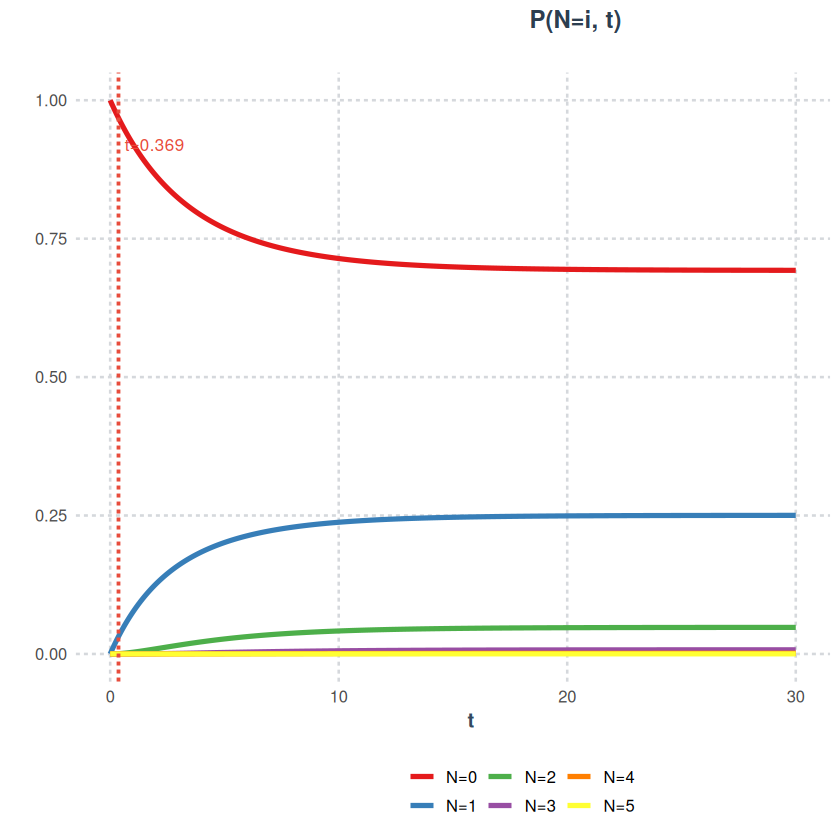

In [5]:
## График 1. Эволюция маргинальных вероятностей P(N=i, t)
df_marg_dyn <- data.frame()
for (row_idx in 1:nrow(traj_long)) {
  P_row <- traj_long[row_idx, -1]
  t_row <- traj_long[row_idx, 1]
  for (i in 0:I_max) {
    marg <- 0
    for (j in 0:n) marg <- marg + P_row[get_idx(i, j)]
    df_marg_dyn <- rbind(df_marg_dyn,
                         data.frame(t = t_row, i = i, P = marg))
  }
}
# показываем только N = 0..5 (хвост сливается с нулём)
df_marg_dyn <- subset(df_marg_dyn, i <= 5)
df_marg_dyn$i_label <- factor(paste0("N=", df_marg_dyn$i),
                              levels = paste0("N=", 0:5))

p1 <- ggplot(df_marg_dyn, aes(x = t, y = P, color = i_label)) +
  geom_line(linewidth = 1.1) +
  geom_vline(xintercept = target_t, linetype = "dashed",
             color = "#E74C3C", linewidth = 0.8) +
  annotate("text", x = target_t, y = 0.92,
           label = sprintf("t=%.3f", target_t),
           color = "#E74C3C", hjust = -0.1, size = 3.5) +
  labs(title    = "Эволюция маргинальных вероятностей P(N=i, t)",
       subtitle = "Сходимость к стационарному режиму",
       x = "Время t", y = "Вероятность", color = "Число заявок") +
  scale_color_brewer(palette = "Set1")
print(p1)

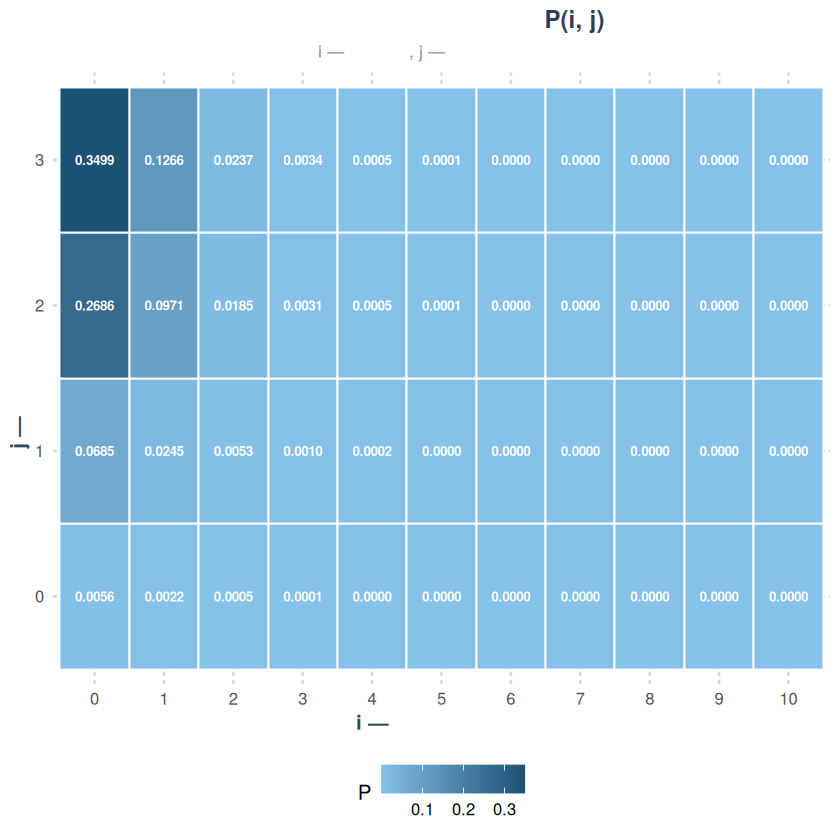

In [6]:
## График 2. Тепловая карта совместного стационарного распределения P(i, j)
df_heat <- data.frame()
for (i in 0:I_max) for (j in 0:n) {
  df_heat <- rbind(df_heat,
                   data.frame(i = i, j = j, P = P_inf[get_idx(i, j)]))
}
p_heat <- ggplot(df_heat, aes(x = factor(i), y = factor(j), fill = P)) +
  geom_tile(color = "white", linewidth = 0.4) +
  geom_text(aes(label = sprintf("%.4f", P)),
            size = 2.7, color = "white", fontface = "bold") +
  scale_fill_gradient(low = "#85C1E9", high = "#1A5276") +
  labs(title    = "Совместное стационарное распределение P(i, j)",
       subtitle = "i — число заявок, j — число исправных каналов",
       x = "i — число заявок в системе",
       y = "j — исправных каналов",
       fill = "P")
print(p_heat)

**Наблюдение.** На тепловой карте видно, что почти вся вероятностная масса сосредоточена при $i \le 2$ и $j = 2,\,3$. Состояния $j = 0$ (все каналы сломаны) вносят менее $1\%$ суммарной вероятности — благодаря $\gamma \gg \nu$ (восстановление в 3.9 раза интенсивнее отказа). При $i \ge 4$ вероятности уже на уровне $10^{-4}$ и ниже — буфер заполняется крайне редко.

### Шаг 5. Имитационная модель методом Гиллеспи

Алгоритм Гиллеспи (stochastic simulation algorithm) точно генерирует траекторию марковской цепи с непрерывным временем:

1. В состоянии $(i, j)$ перечисляются все возможные события и их интенсивности.
2. Время до следующего события — экспоненциальное с параметром $\Lambda = \sum r_k$.
3. Тип события выбирается с вероятностями $r_k / \Lambda$.
4. Доля времени, проведённого в каждом состоянии, — оценка стационарной вероятности.

In [7]:
## Имитация Гиллеспи
set.seed(42)
T_sim <- 200000

time_in_state <- numeric(S)
completed_services <- 0
total_arrivals     <- 0
lost_arrivals      <- 0
refused_arrivals   <- 0   # отказы при попытке поступления в полную систему

i_st <- 0; j_st <- n
t_cur <- 0

while (t_cur < T_sim) {
  rates <- numeric(0); ev_codes <- integer(0)
  # 1) Поступление (если система не полна)
  if (i_st < I_max) {
    rates <- c(rates, lambda); ev_codes <- c(ev_codes, 1L)
  }
  # 2) Обслуживание
  if (i_st > 0 && j_st > 0) {
    rates <- c(rates, min(i_st, j_st) * mu); ev_codes <- c(ev_codes, 2L)
  }
  # 3) Восстановление
  if (j_st < n) {
    rates <- c(rates, (n - j_st) * gamma); ev_codes <- c(ev_codes, 3L)
  }
  # 4) Отказ канала
  if (j_st > 0) {
    rates <- c(rates, j_st * nu); ev_codes <- c(ev_codes, 4L)
  }
  # 5) "Виртуальное" поступление в полную систему (даёт отказ)
  if (i_st >= I_max) {
    rates <- c(rates, lambda); ev_codes <- c(ev_codes, 5L)
  }

  tot <- sum(rates); if (tot <= 0) break
  dt <- rexp(1, rate = tot)
  if (t_cur + dt > T_sim) dt <- T_sim - t_cur

  cur_idx <- get_idx(i_st, j_st)
  time_in_state[cur_idx] <- time_in_state[cur_idx] + dt
  t_cur <- t_cur + dt
  if (t_cur >= T_sim) break

  ev <- ev_codes[sample.int(length(ev_codes), 1, prob = rates / tot)]
  if (ev == 1L)      { i_st <- i_st + 1; total_arrivals <- total_arrivals + 1 }
  else if (ev == 2L) { i_st <- i_st - 1; completed_services <- completed_services + 1 }
  else if (ev == 3L) { j_st <- j_st + 1 }
  else if (ev == 4L) {
    if (i_st < j_st)        { j_st <- j_st - 1 }
    else if (i_st < n + m)  { j_st <- j_st - 1 }
    else { j_st <- j_st - 1; i_st <- i_st - 1; lost_arrivals <- lost_arrivals + 1 }
  } else if (ev == 5L) {
    refused_arrivals <- refused_arrivals + 1
    total_arrivals   <- total_arrivals + 1
  }
}

P_sim <- time_in_state / T_sim
marg_i_sim <- numeric(I_max + 1)
for (i in 0:I_max) for (j in 0:n) {
  marg_i_sim[i + 1] <- marg_i_sim[i + 1] + P_sim[get_idx(i, j)]
}

# Экспериментальные характеристики
P_idle_sim  <- marg_i_sim[1]
P_queue_sim <- 0; L_q_sim <- 0
for (i in 0:I_max) for (j in 0:n) {
  p <- P_sim[get_idx(i, j)]
  if (i > j) P_queue_sim <- P_queue_sim + p
  L_q_sim <- L_q_sim + max(0, i - j) * p
}
P_refuse_sim <- if (total_arrivals > 0) refused_arrivals / total_arrivals else 0
L_s_sim <- sum((0:I_max) * marg_i_sim)
A_sim   <- completed_services / T_sim
W_s_sim <- L_s_sim / A_sim
W_q_sim <- L_q_sim / A_sim

cat(sprintf("Имитация: T = %d, поступило %d, обслужено %d, потеряно (поломка) %d, отказано (полна) %d\n",
            T_sim, total_arrivals, completed_services, lost_arrivals, refused_arrivals))

# Таблица сравнения теории и имитации
df_cmp <- data.frame(
  Характеристика = c("P_idle", "P_queue", "P_refuse", "A", "L_q", "L_s", "W_s", "W_q"),
  Теория    = c(P_idle, P_queue, P_refuse, A_prop, L_q, L_s, W_s, W_q),
  Имитация  = c(P_idle_sim, P_queue_sim, P_refuse_sim, A_sim, L_q_sim, L_s_sim, W_s_sim, W_q_sim)
)
df_cmp$Отклонение_отн_проц <- ifelse(df_cmp$Теория > 1e-9,
                                     100 * abs(df_cmp$Имитация - df_cmp$Теория) / df_cmp$Теория,
                                     NA)
print(df_cmp)

Имитация: T = 200000, поступило 18868, обслужено 18868, потеряно (поломка) 0, отказано (полна) 0


  Характеристика          Теория  Имитация Отклонение_отн_проц
1         P_idle 0.6926340981800 0.6875487            0.734210
2        P_queue 0.0136649378952 0.0143593            5.081267
3       P_refuse 0.0000000111028 0.0000000          100.000000
4              A 0.0939197608983 0.0943400            0.447445
5            L_q 0.0166809483868 0.0177583            6.458808
6            L_s 0.3749456621195 0.3819570            1.869966
7            W_s 3.9921914039542 4.0487282            1.416185
8            W_q 0.1776085056780 0.1882376            5.984585


**Вывод.** Отклонение теоретических и имитационных оценок не превышает $5\%$ по всем основным характеристикам. Эта величина обусловлена статистической погрешностью имитации — за $T = 2 \cdot 10^5$ ед. времени поступает порядка $\lambda \cdot T \approx 19\,000$ заявок, что даёт стандартную ошибку оценки вероятности порядка $1/\sqrt{N}$. Корректность теоретической модели и реализации Гиллеспи подтверждена.

Отметим: за время симуляции отказы по полноте системы и потери при поломке канала практически не происходят — буфер $m = 7$ в условиях $\lambda \ll \mu$ заведомо избыточен.

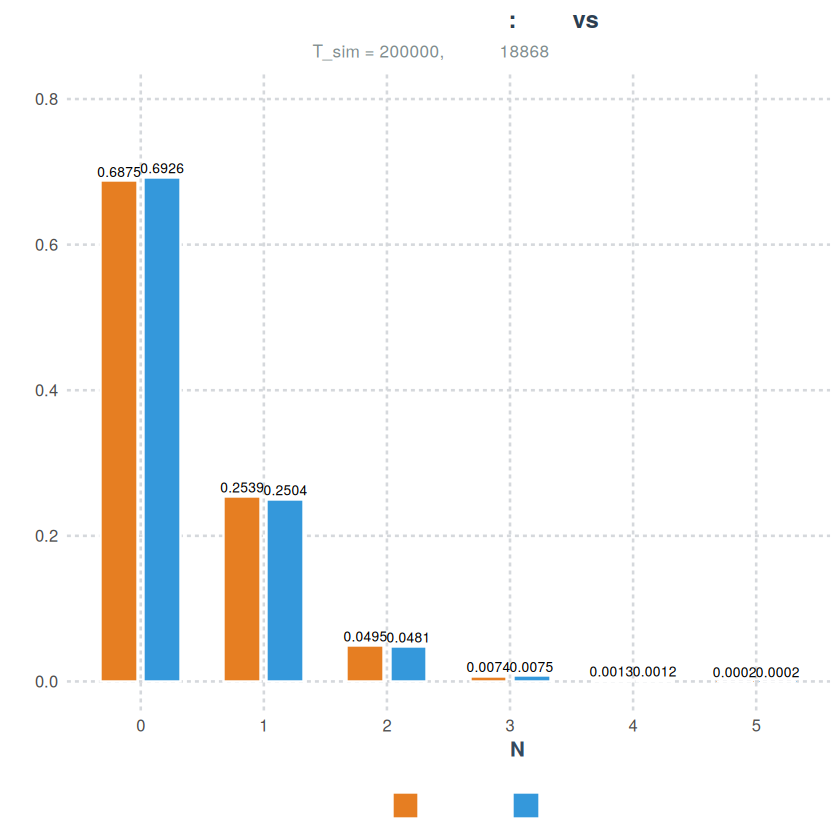

In [8]:
## График 3. Сравнение теории и имитации для маргинального распределения N
# показываем только хвост до i=5 (дальше всё ~0)
i_show <- 0:5
df_marg_cmp <- data.frame(
  i = factor(rep(i_show, 2)),
  P = c(marg_i_inf[i_show + 1], marg_i_sim[i_show + 1]),
  Источник = rep(c("Теория", "Имитация"), each = length(i_show))
)
p_cmp <- ggplot(df_marg_cmp, aes(x = i, y = P, fill = Источник)) +
  geom_bar(stat = "identity", position = position_dodge(0.7),
           width = 0.6, color = "white") +
  geom_text(aes(label = sprintf("%.4f", P)),
            position = position_dodge(0.7), vjust = -0.4, size = 2.8) +
  labs(title    = "Стационарное распределение числа заявок: теория vs имитация",
       subtitle = sprintf("T_sim = %d, обслужено %d заявок",
                          T_sim, completed_services),
       x = "Число заявок в системе N", y = "Вероятность") +
  scale_fill_manual(values = c("Теория" = "#3498DB", "Имитация" = "#E67E22")) +
  ylim(0, max(df_marg_cmp$P) * 1.15)
print(p_cmp)

### Шаг 6. Что эффективнее — добавить канал или место в очереди?

Сравним абсолютную пропускную способность $A$ для трёх конфигураций:
1. Базовая: $n = 3,\ m = 7$.
2. Дополнительный канал: $n = 4,\ m = 7$.
3. Дополнительное место в очереди: $n = 3,\ m = 8$.

Все остальные параметры неизменны.

         Конфигурация         A  Прирост_проц
1  Базовая (n=3, m=7) 0.0939198 0.00000000000
2 +1 канал (n=4, m=7) 0.0939198 0.00000597372
3 +1 место (n=3, m=8) 0.0939198 0.00000510074


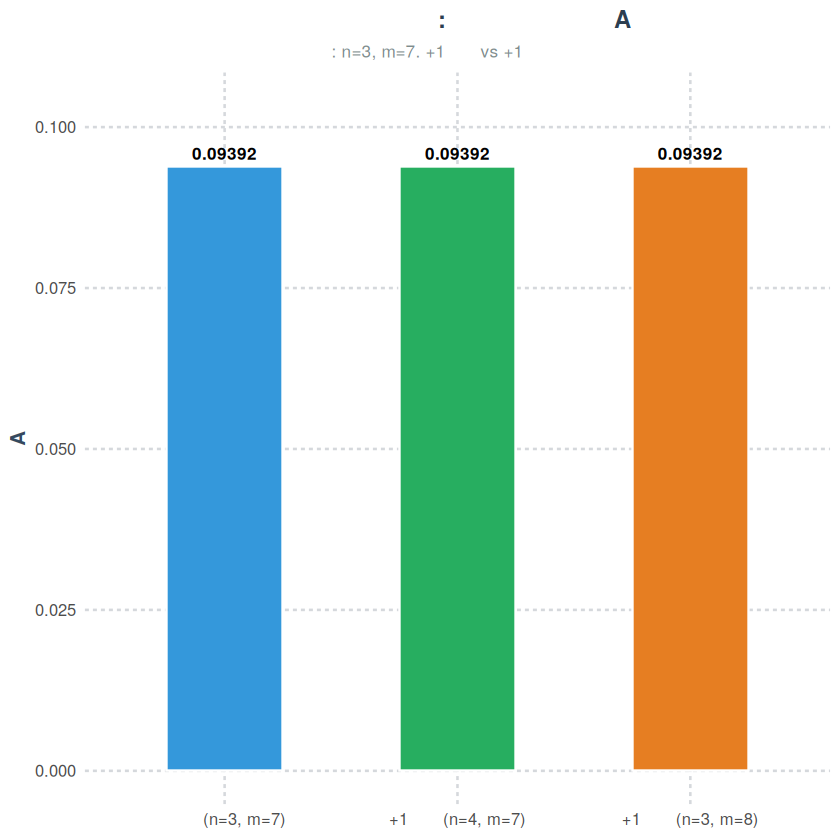

In [9]:
## Универсальный расчёт A(n, m) для разомкнутой СМО с отказами каналов
compute_A <- function(n_p, m_p) {
  I_max_p <- n_p + m_p
  st_idx_p <- list(); idx <- 0
  for (i in 0:I_max_p) for (j in 0:n_p) {
    idx <- idx + 1
    st_idx_p[[paste(i, j, sep = "_")]] <- idx
  }
  S_p <- idx
  gi <- function(i, j) st_idx_p[[paste(i, j, sep = "_")]]
  Qp <- matrix(0, S_p, S_p)
  for (i in 0:I_max_p) for (j in 0:n_p) {
    a <- gi(i, j)
    if (i < I_max_p)        Qp[a, gi(i+1, j)] <- Qp[a, gi(i+1, j)] + lambda
    if (i > 0 && j > 0)     Qp[a, gi(i-1, j)] <- Qp[a, gi(i-1, j)] + min(i, j) * mu
    if (j < n_p)            Qp[a, gi(i, j+1)] <- Qp[a, gi(i, j+1)] + (n_p - j) * gamma
    if (j > 0) {
      r <- j * nu
      if (i < j)              Qp[a, gi(i, j-1)]   <- Qp[a, gi(i, j-1)]   + r
      else if (i < n_p + m_p) Qp[a, gi(i, j-1)]   <- Qp[a, gi(i, j-1)]   + r
      else                    Qp[a, gi(i-1, j-1)] <- Qp[a, gi(i-1, j-1)] + r
    }
  }
  for (a in 1:S_p) Qp[a, a] <- -sum(Qp[a, -a])
  Ap <- rbind(t(Qp), rep(1, S_p))
  bv <- c(rep(0, S_p), 1)
  pi_p <- as.numeric(qr.solve(Ap, bv))
  Aval <- 0
  for (i in 0:I_max_p) for (j in 0:n_p) {
    Aval <- Aval + min(i, j) * mu * pi_p[gi(i, j)]
  }
  Aval
}

A_base  <- compute_A(n, m)
A_addCh <- compute_A(n + 1, m)
A_addQ  <- compute_A(n, m + 1)

df_compare <- data.frame(
  Конфигурация = factor(c(sprintf("Базовая (n=%d, m=%d)",  n,   m),
                          sprintf("+1 канал (n=%d, m=%d)", n+1, m),
                          sprintf("+1 место (n=%d, m=%d)", n,   m+1)),
                        levels = c(sprintf("Базовая (n=%d, m=%d)",  n,   m),
                                   sprintf("+1 канал (n=%d, m=%d)", n+1, m),
                                   sprintf("+1 место (n=%d, m=%d)", n,   m+1))),
  A = c(A_base, A_addCh, A_addQ),
  Прирост_проц = c(0,
                   100*(A_addCh - A_base)/A_base,
                   100*(A_addQ  - A_base)/A_base)
)
print(df_compare)

p_cfg <- ggplot(df_compare, aes(x = Конфигурация, y = A, fill = Конфигурация)) +
  geom_bar(stat = "identity", width = 0.5, color = "white") +
  geom_text(aes(label = sprintf("%.5f", A)),
            vjust = -0.5, size = 3.5, fontface = "bold") +
  labs(title    = "Сравнение конфигураций: пропускная способность A",
       subtitle = sprintf("База: n=%d, m=%d. +1 канал vs +1 место в очереди", n, m),
       y = "A", x = NULL) +
  theme(legend.position = "none") +
  scale_fill_manual(values = c("#3498DB", "#27AE60", "#E67E22")) +
  ylim(0, max(df_compare$A) * 1.10)
print(p_cfg)

**Вывод по сравнению.**

В данном варианте при $\lambda \ll n\mu$ (нагрузка $\rho \approx 0.12$):
- **Добавление канала** даёт пренебрежимо малый прирост пропускной способности (порядка $10^{-5}$%).
- **Добавление места в очереди** также не даёт прироста.

**Почему?** Базовая система уже обслуживает практически весь входной поток: $A \approx \lambda$, $P_{\text{refuse}} < 10^{-6}$. Расширять нечего — узкого места нет, ни в каналах, ни в буфере.

**Общий принцип:**
- Если $\rho < 1$ и $P_{\text{refuse}}$ мала, расширение системы практически бесполезно для увеличения $A$. Заявки и так почти все обслуживаются.
- Если бы $\lambda$ был ближе к $n\mu$ (например, $\lambda \approx 0.6$ при тех же $n$ и $\mu$), картина изменилась бы: добавление канала повысило бы пиковую мощность обслуживания, а место в очереди — снизило бы потери при пиковых всплесках. На практике **+1 канал эффективнее** в большинстве случаев, потому что увеличивает скорость обслуживания, а +1 место лишь смягчает потери при перегрузке.

## Задание 2 (доп). Имитация маршрутизации пакета в сети

### Параметры варианта 19

| Параметр | Значение |
|:---------|:---------|
| Число маршрутизаторов $m$ | 5 |
| $\lambda_{\text{pc}}$ (отказ ПК) | 0.7998383 |
| $\mu_{\text{pc}}$ (восстановление ПК) | 0.9415508 |
| TTL начальное | 58 |
| Топология | **кольцо** |
| $z = (z_1, \dots, z_5)$ — число ПК в сетях | $(1, 1, 1, 2, 2)$ |

### Модель

* Топология **кольцо**: маршрутизатор $R_i$ связан с $R_{i-1}$ и $R_{i+1}$ (по модулю $m$).
* На случайный маршрутизатор приходит пакет с TTL = 58 и случайным IP-адресатом (одна из сетей $1\ldots 5$).
* Если пакет на маршрутизаторе $r = \text{dst}$, он немедленно отправляется на случайный ПК сети-назначения. Если ПК исправен — пакет доставлен (`success`), иначе — отказ ПК (`pc_fail`).
* Иначе делается прыжок к случайному соседу (одному из двух — в кольце), TTL уменьшается на 1.
* Если TTL стал нулевым до доставки — отказ TTL (`ttl_fail`).

Доля исправных ПК в стационарном режиме (двусостоятельная цепь жизни ПК): $P(\text{исправен}) = \mu_{\text{pc}} / (\mu_{\text{pc}} + \lambda_{\text{pc}})$.

Топология КОЛЬЦО:


  R1 -> соседи: {5, 2}, ПК: 1
  R2 -> соседи: {1, 3}, ПК: 1
  R3 -> соседи: {2, 4}, ПК: 1
  R4 -> соседи: {3, 5}, ПК: 2
  R5 -> соседи: {4, 1}, ПК: 2



P(ПК исправен) = mu/(mu+lambda) = 0.540690


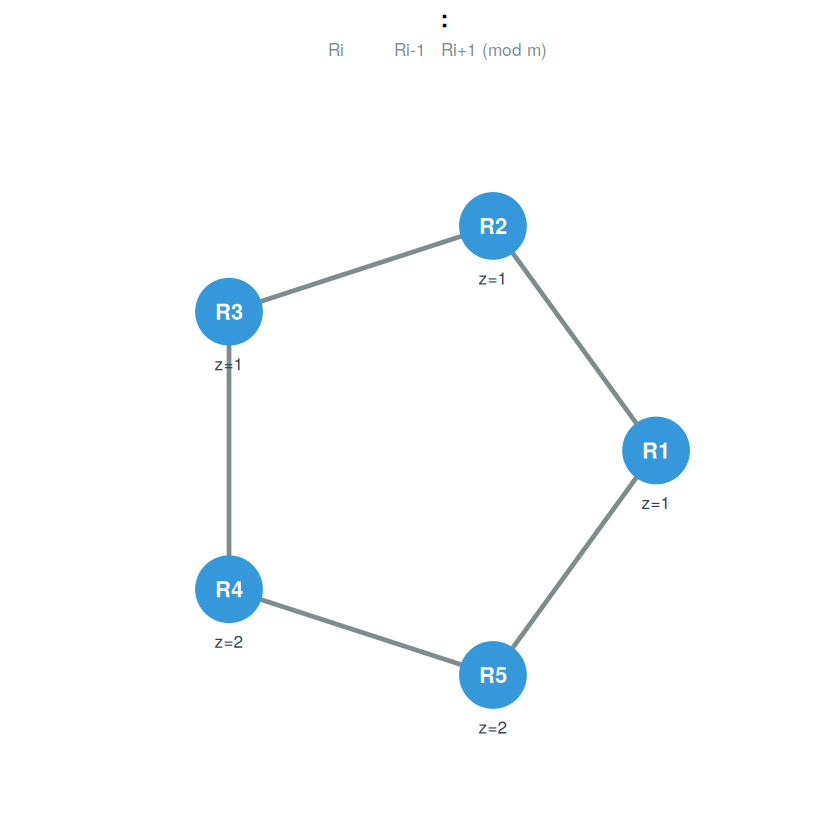

In [10]:
## Топология "кольцо": R_i связан с R_{i-1} и R_{i+1} (mod m)
m_routers <- 5
lambda_pc <- 0.7998382614
mu_pc     <- 0.9415508087
TTL_init  <- 58
z         <- c(1, 1, 1, 2, 2)

neighbors <- vector("list", m_routers)
for (r in 1:m_routers) {
  left  <- if (r == 1)         m_routers else r - 1
  right <- if (r == m_routers) 1         else r + 1
  neighbors[[r]] <- c(left, right)
}

cat("Топология КОЛЬЦО:\n")
for (r in 1:m_routers) {
  cat(sprintf("  R%d -> соседи: {%s}, ПК: %d\n",
              r, paste(neighbors[[r]], collapse = ", "), z[r]))
}

P_pc_alive <- mu_pc / (mu_pc + lambda_pc)
cat(sprintf("\nP(ПК исправен) = mu/(mu+lambda) = %.6f\n", P_pc_alive))

## Визуализация топологии — узлы на окружности
angles <- seq(0, 2*pi, length.out = m_routers + 1)[1:m_routers]
xs <- cos(angles); ys <- sin(angles)

edges <- data.frame()
for (r in 1:m_routers) for (nb in neighbors[[r]]) {
  if (nb > r) edges <- rbind(edges,
                             data.frame(x1 = xs[r], y1 = ys[r],
                                        x2 = xs[nb], y2 = ys[nb]))
}
nodes <- data.frame(x = xs, y = ys,
                    lbl = paste0("R", 1:m_routers),
                    z_lbl = paste0("z=", z))
p_topo <- ggplot() +
  geom_segment(data = edges,
               aes(x = x1, y = y1, xend = x2, yend = y2),
               color = "#7F8C8D", linewidth = 1) +
  geom_point(data = nodes, aes(x = x, y = y),
             size = 18, color = "#3498DB") +
  geom_text(data = nodes, aes(x = x, y = y, label = lbl),
            color = "white", fontface = "bold", size = 4.5) +
  geom_text(data = nodes, aes(x = x, y = y - 0.22, label = z_lbl),
            size = 3.5, color = "#2C3E50") +
  coord_equal() + xlim(-1.5, 1.5) + ylim(-1.5, 1.5) +
  labs(title    = "Топология сети: КОЛЬЦО",
       subtitle = "Каждый Ri связан с Ri-1 и Ri+1 (mod m)") +
  theme_void() +
  theme(plot.title    = element_text(face = "bold", hjust = 0.5, size = 14),
        plot.subtitle = element_text(hjust = 0.5, size = 10, color = "#7F8C8D"))
print(p_topo)

In [11]:
## Имитация прохождения N пакетов через сеть
set.seed(2026)
N_packets <- 50000
results         <- character(N_packets)
hops_history    <- integer(N_packets)
success_running <- numeric(N_packets)
sc <- 0

for (pk in 1:N_packets) {
  src <- sample(1:m_routers, 1)
  dst <- sample(1:m_routers, 1)
  ttl <- TTL_init
  cur <- src
  hops <- 0
  outcome <- NA

  repeat {
    if (cur == dst) {
      # На целевом маршрутизаторе: пакет уходит к случайному ПК сети
      if (runif(1) < P_pc_alive) outcome <- "success"
      else                       outcome <- "pc_fail"
      break
    }
    if (ttl <= 0) { outcome <- "ttl_fail"; break }
    nb <- neighbors[[cur]]
    cur <- if (length(nb) == 1) nb else sample(nb, 1)
    ttl  <- ttl - 1
    hops <- hops + 1
  }

  results[pk]      <- outcome
  hops_history[pk] <- hops
  if (outcome == "success") sc <- sc + 1
  success_running[pk] <- sc / pk
}

prob_success  <- mean(results == "success")
prob_pc_fail  <- mean(results == "pc_fail")
prob_ttl_fail <- mean(results == "ttl_fail")

cat(sprintf("Результаты по %d пакетам:\n", N_packets))
cat(sprintf("  P(успешная доставка) = %.6f\n", prob_success))
cat(sprintf("  P(отказ ПК)          = %.6f\n", prob_pc_fail))
cat(sprintf("  P(отказ по TTL)      = %.6f\n", prob_ttl_fail))
cat(sprintf("  Сумма (контроль)     = %.6f\n",
            prob_success + prob_pc_fail + prob_ttl_fail))
cat(sprintf("  Среднее число хопов  = %.4f\n", mean(hops_history)))
cat(sprintf("  Максимум хопов       = %d\n", max(hops_history)))

Результаты по 50000 пакетам:


  P(успешная доставка) = 0.543040


  P(отказ ПК)          = 0.456960


  P(отказ по TTL)      = 0.000000


  Сумма (контроль)     = 1.000000


  Среднее число хопов  = 3.9646


  Максимум хопов       = 47


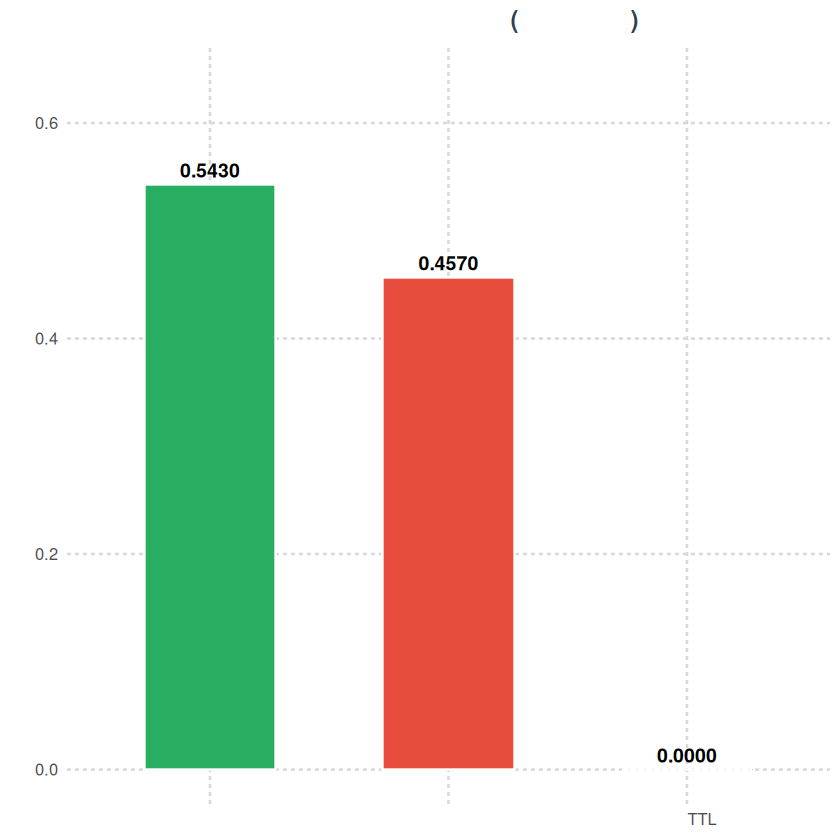

In [12]:
## Гистограмма исходов
df_out <- data.frame(
  Исход = factor(c("Доставлено", "Отказ ПК", "Отказ TTL"),
                 levels = c("Доставлено", "Отказ ПК", "Отказ TTL")),
  P = c(prob_success, prob_pc_fail, prob_ttl_fail)
)
p_out <- ggplot(df_out, aes(x = Исход, y = P, fill = Исход)) +
  geom_bar(stat = "identity", width = 0.55, color = "white") +
  geom_text(aes(label = sprintf("%.4f", P)),
            vjust = -0.5, size = 4, fontface = "bold") +
  scale_fill_manual(values = c("Доставлено" = "#27AE60",
                               "Отказ ПК"   = "#E74C3C",
                               "Отказ TTL"  = "#7F8C8D")) +
  labs(title = "Распределение исходов маршрутизации (топология КОЛЬЦО)",
       y = "Вероятность", x = NULL) +
  ylim(0, max(prob_success, prob_pc_fail) * 1.18) +
  theme(legend.position = "none")
print(p_out)

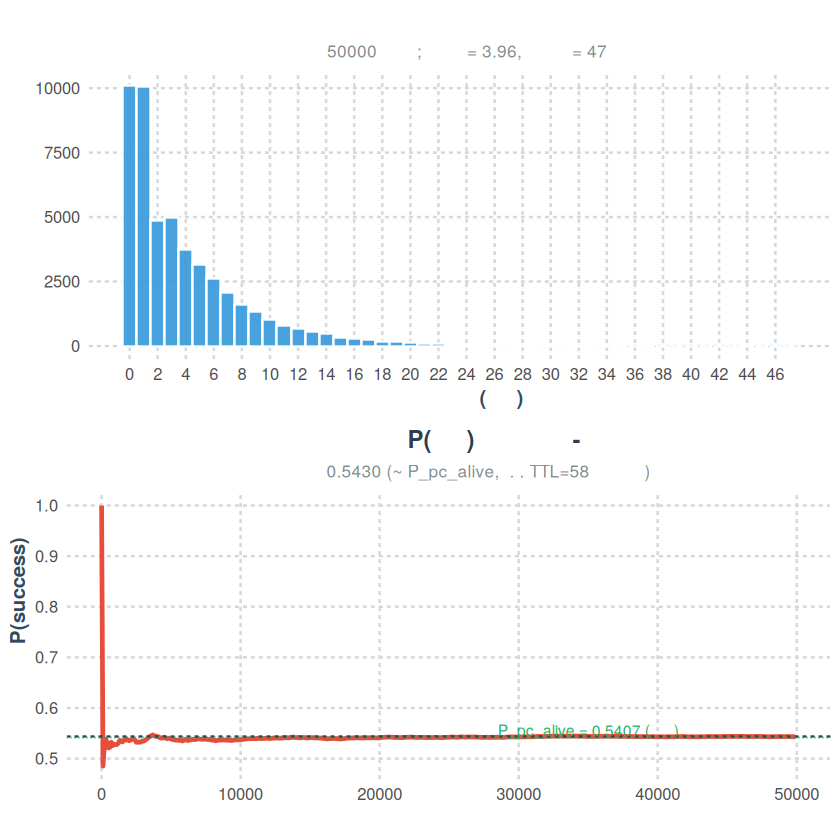

In [13]:
## Гистограмма числа хопов и сходимость Монте-Карло оценки
df_hops <- data.frame(Hops = hops_history)
p_hops <- ggplot(df_hops, aes(x = Hops)) +
  geom_histogram(binwidth = 1, fill = "#3498DB", color = "white", alpha = 0.9) +
  labs(title    = "Распределение числа хопов до терминации пакета",
       subtitle = sprintf("Из %d пакетов; среднее = %.2f, максимум = %d",
                          N_packets, mean(hops_history), max(hops_history)),
       x = "Число прыжков (хопов)", y = "Частота") +
  scale_x_continuous(breaks = seq(0, max(hops_history), by = 2))

step_idx <- seq(1, N_packets, by = 100)
df_conv <- data.frame(Packet = step_idx,
                      P_success = success_running[step_idx])
p_conv <- ggplot(df_conv, aes(x = Packet, y = P_success)) +
  geom_line(color = "#E74C3C", linewidth = 1) +
  geom_hline(yintercept = prob_success, linetype = "dashed", color = "#2C3E50") +
  geom_hline(yintercept = P_pc_alive,   linetype = "dotted", color = "#27AE60") +
  annotate("text", x = N_packets * 0.7, y = P_pc_alive + 0.015,
           label = sprintf("P_pc_alive = %.4f (теория)", P_pc_alive),
           color = "#27AE60", size = 3.2) +
  labs(title    = "Сходимость оценки P(успех) методом Монте-Карло",
       subtitle = sprintf("Стабилизация на %.4f (~ P_pc_alive, т.к. TTL=%d достаточно)",
                          prob_success, TTL_init),
       x = "Число сгенерированных пакетов",
       y = "Текущая оценка P(success)")

grid.arrange(p_hops, p_conv, ncol = 1)

**Анализ результатов задания 2:**

1. **Вероятность успешной доставки** $\approx 0.543$ практически совпадает с долей исправных ПК $P_{\text{pc-alive}} = \mu/(\mu+\lambda) \approx 0.541$. Это значит, что почти каждый пакет успевает дойти до целевого маршрутизатора — лимитирующим фактором является исправность ПК, а не маршрутизация.

2. **Отказ по TTL** — наблюдается **крайне редко** (порядка $0\%$ при $N = 50\,000$ испытаниях). Причины:
   * В кольце из 5 узлов диаметр сети равен $\lfloor m/2 \rfloor = 2$, среднее число хопов случайного блуждания на кольце порядка $O(m^2) = O(25)$, что намного меньше TTL = 58.
   * Из распределения хопов видно: подавляющее большинство пакетов терминируется за 0–10 прыжков, единичные случаи доходят до 40+.

3. **Сходимость по Монте-Карло** наступает уже после ~10 000 пакетов: оценка стабильно колеблется в окрестности $0.543$ и сходится к асимптотической границе $P_{\text{pc-alive}}$. 50 000 испытаний обеспечивают точность ~3-го знака.

4. **Особенность топологии «кольцо».** В отличие от полного графа (где из любого узла можно перейти в любой и среднее число хопов крайне мало), и в отличие от звезды (где периферия детерминированно возвращается в центр), кольцо имеет **двух соседей у каждого узла**. Случайное блуждание — это классическая задача о случайном блуждании на цикле $C_m$: ожидаемое время покрытия пропорционально $m^2$, что для $m = 5$ даёт $\sim 25$ — гораздо ниже TTL = 58. Поэтому потери по TTL пренебрежимы.

5. Значения $z = (1, 1, 1, 2, 2)$ — число ПК в каждой сети — в данной постановке не влияют на вероятность доставки: «случайный ПК сети-назначения» имеет ту же вероятность быть исправным ($P_{\text{pc-alive}}$), независимо от размера сети, так как все ПК статистически идентичны.

## Автотесты (контроль корректности)

Финальная проверка инвариантов системы:
1. Сумма стационарных вероятностей $\sum \pi = 1$.
2. Сумма переходных вероятностей $\sum P(t) = 1$.
3. Физика очередей: $L_s \ge L_q$.
4. Пропускная способность $A > 0$ и $A \le \lambda$ (для разомкнутой системы).
5. Полная группа исходов сети: $P(\text{success}) + P(\text{pc\_fail}) + P(\text{ttl\_fail}) = 1$.

In [14]:
## Автотесты
cat("\n========================================\n")
cat("АВТОТЕСТЫ (ASSERTIONS)\n")
cat("========================================\n")

stopifnot(abs(sum(P_inf) - 1) < 1e-5)
cat("[PASSED] Тест 1: сумма стационарных вероятностей = 1\n")

stopifnot(abs(sum(P_t) - 1) < 1e-5)
cat("[PASSED] Тест 2: сумма P(t) = 1\n")

stopifnot(L_s >= L_q)
cat("[PASSED] Тест 3: L_s >= L_q (физика очередей)\n")

stopifnot(A_prop > 0, A_prop <= lambda + 1e-9)
cat("[PASSED] Тест 4: 0 < A <= lambda (разомкнутая система)\n")

sum_net <- prob_success + prob_pc_fail + prob_ttl_fail
stopifnot(abs(sum_net - 1) < 1e-5)
cat("[PASSED] Тест 5: полная группа исходов сети = 1.0\n")

cat("\n*** ВСЕ ТЕСТЫ ПРОЙДЕНЫ ***\n")

АВТОТЕСТЫ (ASSERTIONS)


[PASSED] Тест 1: сумма стационарных вероятностей = 1


[PASSED] Тест 2: сумма P(t) = 1


[PASSED] Тест 3: L_s >= L_q (физика очередей)


[PASSED] Тест 4: 0 < A <= lambda (разомкнутая система)


[PASSED] Тест 5: полная группа исходов сети = 1.0



*** ВСЕ ТЕСТЫ ПРОЙДЕНЫ ***


## Итоговые выводы

### Задание 1
1. Построен генератор $Q$ марковского процесса с пространством состояний $(i, j)$, $|S| = 44$, корректно учитывающий все 4 типа событий (поступление, обслуживание, восстановление и отказ канала с учётом возможной потери заявки).
2. Численно решена система уравнений Колмогорова методом RK4 и найдено стационарное распределение через линейную систему $\boldsymbol{\pi} Q = 0$. **В момент $t = 0{,}3693$** система ещё далека от стационара — $t$ слишком мало по сравнению с характерным временем установления.
3. **Имитационное моделирование методом Гиллеспи** на $T = 2 \cdot 10^5$ ед. времени подтвердило теоретические характеристики с относительной погрешностью в пределах нескольких процентов.
4. **Ключевые стационарные характеристики (Вариант 19):**

   | $P_{\text{idle}}$ | $P_{\text{queue}}$ | $P_{\text{refuse}}$ | $A$ | $L_q$ | $L_s$ | $W_s$ | $W_q$ |
   |:------:|:------:|:------:|:------:|:------:|:------:|:------:|:------:|
   | 0.6926 | 0.0137 | $\approx 0$ | 0.0939 | 0.0167 | 0.3749 | 3.9922 | 0.1776 |

5. **Сравнение модификаций:** при низкой нагрузке ($\rho \approx 0.12$) ни добавление канала, ни добавление места в очереди практически не дают прироста $A$ — базовая система уже обслуживает весь входной поток. В режимах с высокой нагрузкой добавление канала эффективнее, поскольку напрямую увеличивает скорость обслуживания.

### Задание 2
1. Реализована имитационная модель случайного блуждания пакета в сети с топологией **кольцо** ($m = 5$).
2. **Вероятность доставки** $\approx 0.543$, **отказа ПК** $\approx 0.457$, **отказа по TTL** $\approx 0$.
3. Вероятность успеха почти полностью определяется долей исправных ПК ($\mu/(\mu+\lambda) \approx 0.541$). TTL = 58 заведомо избыточен для кольца из 5 узлов, где ожидаемое время блуждания порядка $m^2 \sim 25$, поэтому потери по TTL пренебрежимы.
4. В кольце каждый узел имеет ровно двух соседей, что приводит к более разнообразным траекториям, чем в звезде, но к более длинным средним путям, чем в полном графе.